In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from itertools import product

import cmcrameri as cmc  # noqa: F401
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml
from matplotlib import gridspec
from unseen_awg.plotting_utils import (
    add_label_to_axes,
    transition_init_time_plot,
    transition_lead_time_plot,
    transition_valid_time_plot,
)

from analyses.utils import (
    extract_datapoints_in_years,
    extract_n_years_from_trajectory,
    load_trajectories,
    stack_to_dim,
)

In [3]:
mpl.rc_file("../../matplotlibrc")
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

In [4]:
n_seeds = 500
sigmas = [0.25, 2.5, 250]
blocksizes = [1, 30, 44]


paths_trajectories = [
    os.path.join(
        paths["dir_simulations"],
        "wg_reforecasts_5e06172f_f40e9460_1e69bda9_d13ad10f",
        f"{seed}_{sigma:g}_{blocksize}",
    )
    for (seed, sigma, blocksize) in product(np.arange(n_seeds), sigmas, blocksizes)
]

N_YEARS = 21
YEAR_MIN = 2003
YEAR_MAX = YEAR_MIN + N_YEARS - 1

THRESHOLD = 1

In [5]:
ds_era = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_era5",
        "rechunk_combined_facc0e91.zarr",
    ),
    decode_timedelta=True,
)

ds_era = ds_era.assign_coords(valid_time=ds_era.init_time + ds_era.lead_time)

In [6]:
ground_truth = (
    extract_datapoints_in_years(
        stack_to_dim(ds_era),
        year_max=YEAR_MAX,
        year_min=YEAR_MIN,
    ).swap_dims({"datapoint": "valid_time"})
).expand_dims()

excl_vars = ["tp"]
sel_vars = [v for v in ground_truth.data_vars if v not in excl_vars]

trajectories = load_trajectories(paths_trajectories)

print("load trajectories")
trimmed_trajs = []
for traj in trajectories:
    trimmed_trajs.append(
        extract_n_years_from_trajectory(
            traj=traj,
            n_years=N_YEARS,
            new_start_year=ground_truth.valid_time.dt.year.min().data,
        )
    )
trimmed_trajs = xr.combine_by_coords(trimmed_trajs)


load trajectories


In [7]:
font_kwargs = dict(fontweight="bold", fontsize="large")

# plots for different values of $\tau$

In [8]:
dir_trajectory_diagnostics = os.path.join(paths["dir_images"], "trajectory_diagnostics")
os.makedirs(dir_trajectory_diagnostics, exist_ok=True)

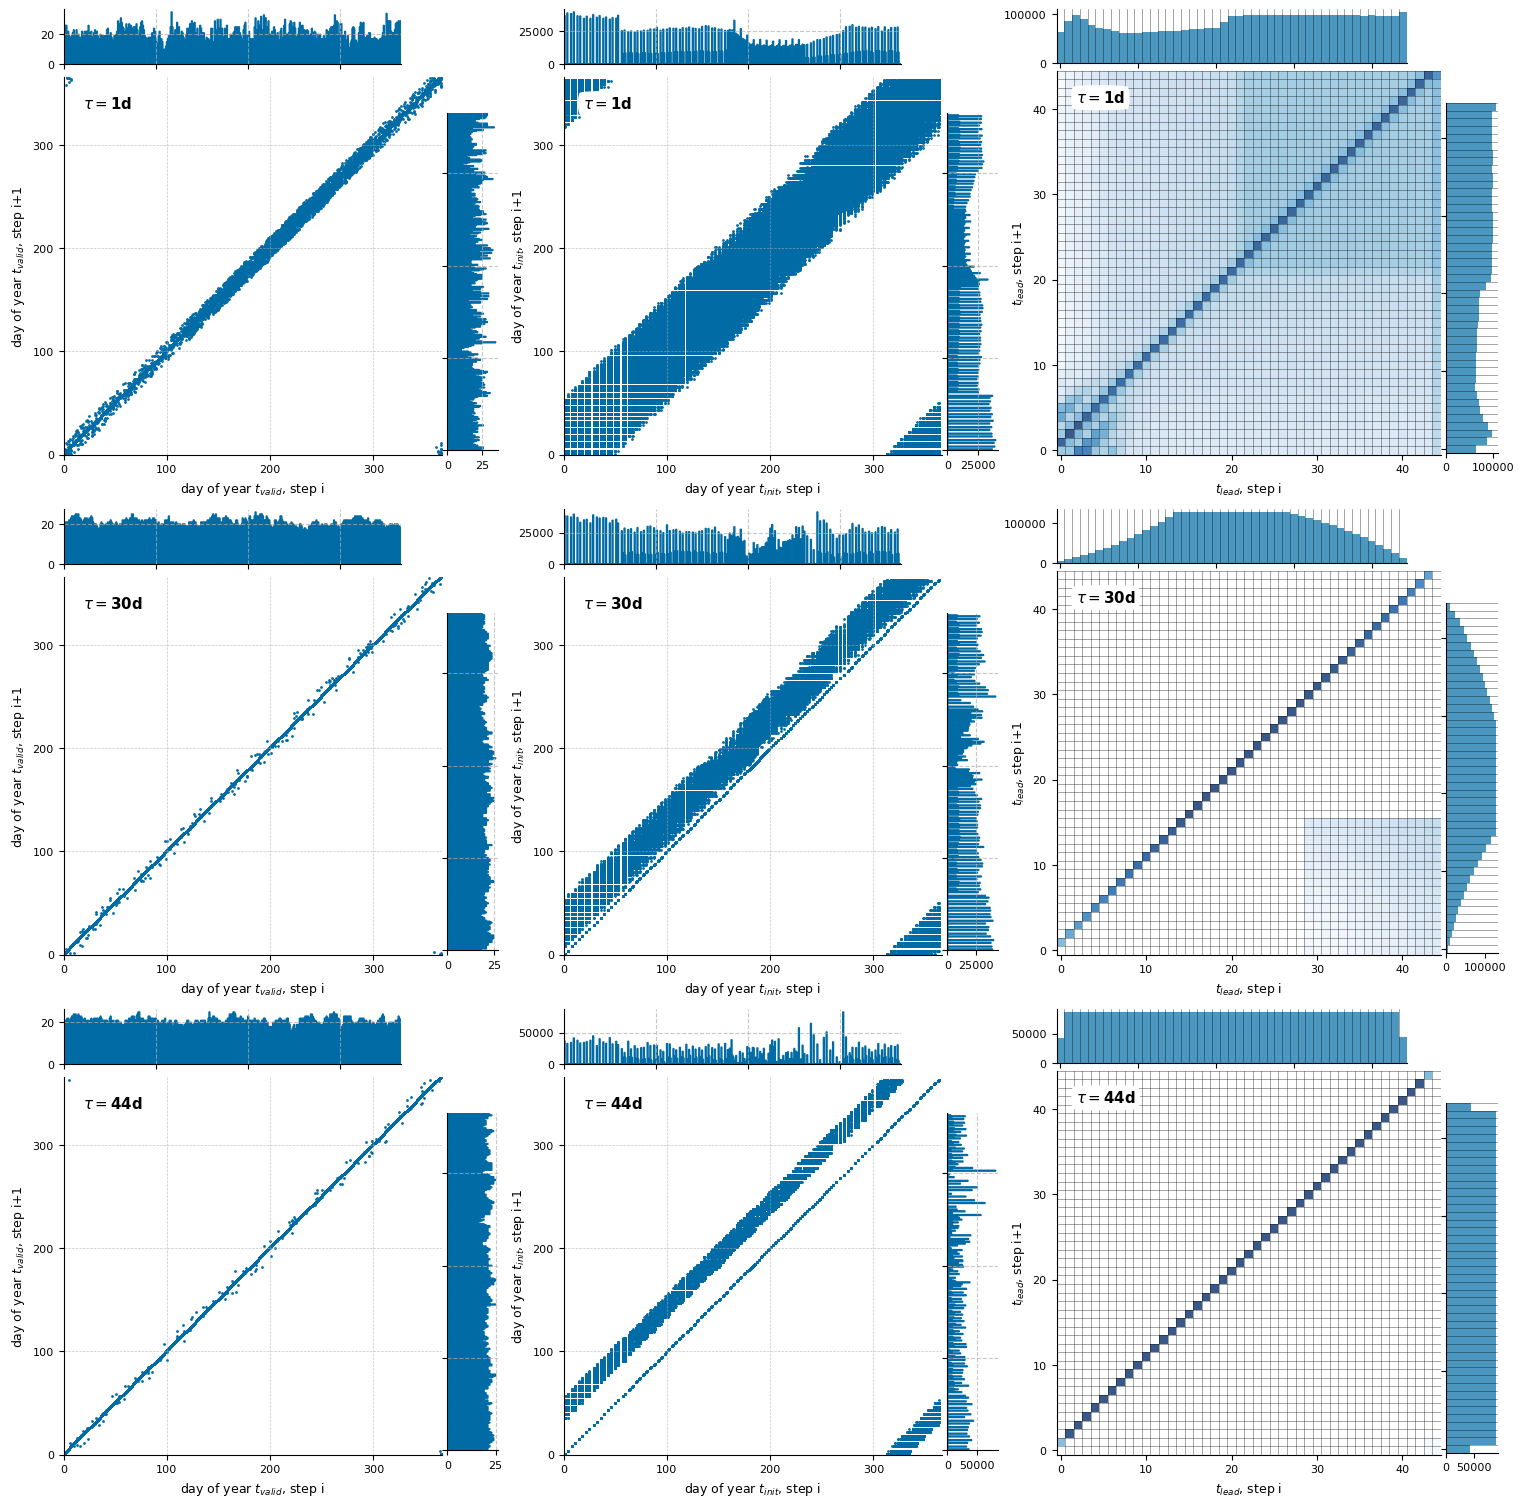

In [9]:
sigma = 2.5
ratio_hist = 0.15

only_jumps = False

base_size = 5
n_rows = len(trimmed_trajs.blocksize)
n_cols = 3

fig = plt.figure(figsize=(base_size * n_cols, base_size * n_rows))


gs = gridspec.GridSpec(
    n_rows,
    n_cols,
    figure=fig,
)


for i, tau in enumerate(trimmed_trajs.blocksize):
    gs_sub = gridspec.GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=gs[i, 0],
        width_ratios=[1, ratio_hist],
        height_ratios=[ratio_hist, 1],
    )
    ax_main = fig.add_subplot(gs_sub[1, 0])
    ax_right_marginal = fig.add_subplot(gs_sub[1, 1], sharey=ax_main)
    ax_upper_marginal = fig.add_subplot(gs_sub[0, 0], sharex=ax_main)

    transition_valid_time_plot(
        ax_joint=ax_main,
        ax_top=ax_upper_marginal,
        ax_right=ax_right_marginal,
        traj=trimmed_trajs.sel(blocksize=tau, sigma=sigma).squeeze(),
        only_jumps=only_jumps,
    )
    add_label_to_axes(
        ax_main,
        r"$\tau =$" + f"{tau.data}d",
        ax_xpos=0.05,
        ax_ypos=0.95,
        **font_kwargs,
        zorder=20,
    )

    gs_sub = gridspec.GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=gs[i, 1],
        width_ratios=[1, ratio_hist],
        height_ratios=[ratio_hist, 1],
    )
    ax_main = fig.add_subplot(gs_sub[1, 0])
    ax_right_marginal = fig.add_subplot(gs_sub[1, 1], sharey=ax_main)
    ax_upper_marginal = fig.add_subplot(gs_sub[0, 0], sharex=ax_main)

    transition_init_time_plot(
        ax_joint=ax_main,
        ax_top=ax_upper_marginal,
        ax_right=ax_right_marginal,
        traj=trimmed_trajs.sel(blocksize=tau, sigma=sigma).squeeze(),
        only_jumps=only_jumps,
    )
    add_label_to_axes(
        ax_main,
        r"$\tau =$" + f"{tau.data}d",
        ax_xpos=0.05,
        ax_ypos=0.95,
        **font_kwargs,
        zorder=20,
    )

    gs_sub = gridspec.GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=gs[i, 2],
        width_ratios=[1, ratio_hist],
        height_ratios=[ratio_hist, 1],
    )
    ax_main = fig.add_subplot(gs_sub[1, 0])
    ax_right_marginal = fig.add_subplot(gs_sub[1, 1], sharey=ax_main)
    ax_upper_marginal = fig.add_subplot(gs_sub[0, 0], sharex=ax_main)

    transition_lead_time_plot(
        ax_joint=ax_main,
        ax_top=ax_upper_marginal,
        ax_right=ax_right_marginal,
        traj=trimmed_trajs.sel(blocksize=tau, sigma=sigma).squeeze(),
        only_jumps=only_jumps,
    )
    add_label_to_axes(
        ax_main,
        r"$\tau =$" + f"{tau.data}d",
        ax_xpos=0.05,
        ax_ypos=0.95,
        **font_kwargs,
        zorder=20,
    )

    # for some reason setting the ticks within the function didn't work.
    ax_main.set_xticks(np.arange(0, 44, 10))
    ax_main.set_yticks(np.arange(0, 44, 10))

plt.savefig(
    os.path.join(
        dir_trajectory_diagnostics,
        f"different_blocksizes_jumps_{only_jumps}.png",
    )
)

# Plots for different values of $\sigma$

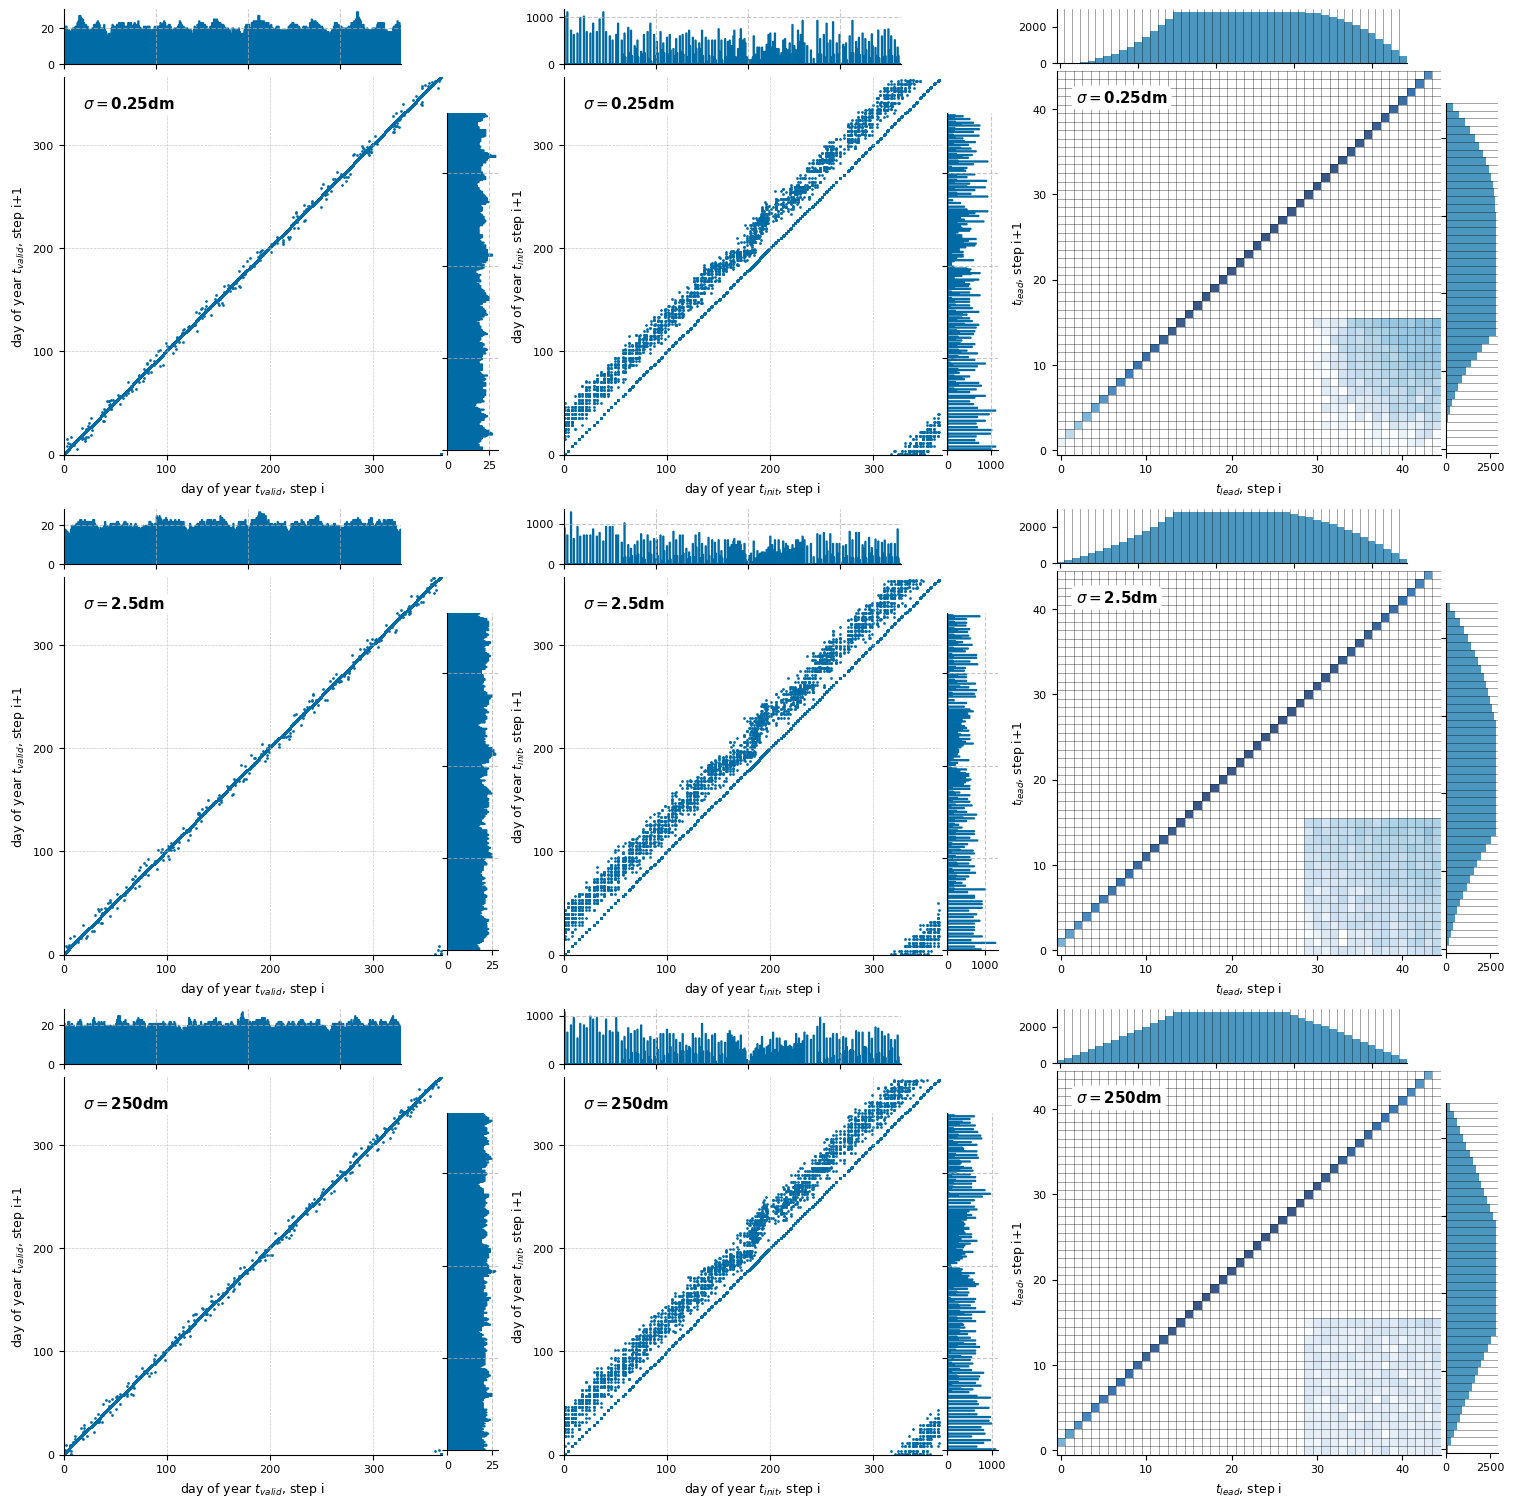

In [10]:
tau = 30
ratio_hist = 0.15

only_jumps = False

base_size = 5
n_rows = len(trimmed_trajs.sigma)
n_cols = 3

fig = plt.figure(figsize=(base_size * n_rows, base_size * n_cols))


gs = gridspec.GridSpec(
    n_rows,
    n_cols,
    figure=fig,
)


for i, sigma in enumerate(trimmed_trajs.sigma):
    gs_sub = gridspec.GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=gs[i, 0],
        width_ratios=[1, ratio_hist],
        height_ratios=[ratio_hist, 1],
    )
    ax_main = fig.add_subplot(gs_sub[1, 0])
    ax_right_marginal = fig.add_subplot(gs_sub[1, 1], sharey=ax_main)
    ax_upper_marginal = fig.add_subplot(gs_sub[0, 0], sharex=ax_main)

    transition_valid_time_plot(
        ax_joint=ax_main,
        ax_top=ax_upper_marginal,
        ax_right=ax_right_marginal,
        traj=trimmed_trajs.sel(blocksize=tau, sigma=sigma, seed=slice(0, 10)).squeeze(),
        only_jumps=only_jumps,
    )
    add_label_to_axes(
        ax_main,
        r"$\sigma=$" + f"{sigma.data:g}dm",
        ax_xpos=0.05,
        ax_ypos=0.95,
        **font_kwargs,
        zorder=20,
    )

    gs_sub = gridspec.GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=gs[i, 1],
        width_ratios=[1, ratio_hist],
        height_ratios=[ratio_hist, 1],
    )
    ax_main = fig.add_subplot(gs_sub[1, 0])
    ax_right_marginal = fig.add_subplot(gs_sub[1, 1], sharey=ax_main)
    ax_upper_marginal = fig.add_subplot(gs_sub[0, 0], sharex=ax_main)

    transition_init_time_plot(
        ax_joint=ax_main,
        ax_top=ax_upper_marginal,
        ax_right=ax_right_marginal,
        traj=trimmed_trajs.sel(blocksize=tau, sigma=sigma, seed=slice(0, 10)).squeeze(),
        only_jumps=only_jumps,
    )
    add_label_to_axes(
        ax_main,
        r"$\sigma=$" + f"{sigma.data:g}dm",
        ax_xpos=0.05,
        ax_ypos=0.95,
        **font_kwargs,
        zorder=20,
    )

    gs_sub = gridspec.GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=gs[i, 2],
        width_ratios=[1, ratio_hist],
        height_ratios=[ratio_hist, 1],
    )
    ax_main = fig.add_subplot(gs_sub[1, 0])
    ax_right_marginal = fig.add_subplot(gs_sub[1, 1], sharey=ax_main)
    ax_upper_marginal = fig.add_subplot(gs_sub[0, 0], sharex=ax_main)

    transition_lead_time_plot(
        ax_joint=ax_main,
        ax_top=ax_upper_marginal,
        ax_right=ax_right_marginal,
        traj=trimmed_trajs.sel(blocksize=tau, sigma=sigma, seed=slice(0, 10)).squeeze(),
        only_jumps=only_jumps,
    )
    # for some reason setting the ticks within the function didn't work.
    ax_main.set_xticks(np.arange(0, 44, 10))
    ax_main.set_yticks(np.arange(0, 44, 10))

    add_label_to_axes(
        ax_main,
        r"$\sigma=$" + f"{sigma.data:g}dm",
        ax_xpos=0.05,
        ax_ypos=0.95,
        **font_kwargs,
        zorder=20,
    )


plt.savefig(
    os.path.join(
        dir_trajectory_diagnostics,
        f"different_sigma_tau-{tau}_jumps-{only_jumps}.png",
    )
)